In [6]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image
from IPython.display import display

Pre-OCR suitability check: 100%|██████████| 434/434 [00:23<00:00, 18.43it/s]


Pre-OCR Suitability Summary:
Total images        : 434
Suitable for OCR    : 430 (99.08%)
NOT suitable for OCR: 4 (0.92%)

Saved → E:\OCR\pre_ocr_suitability.csv


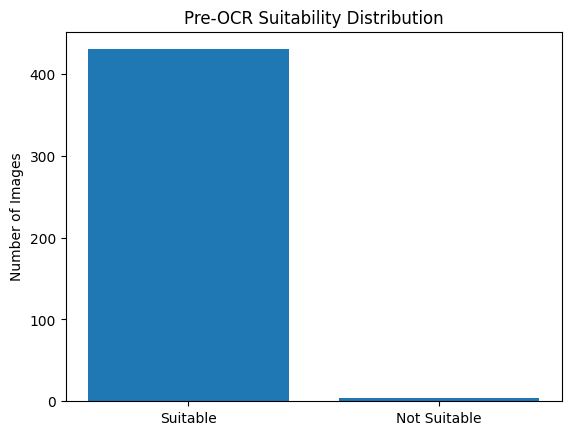

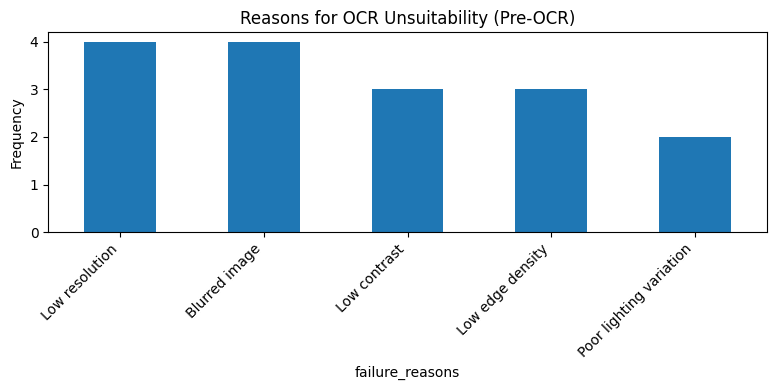


Example OCR-unsuitable images:

Score: 0.15
Reasons: Low resolution; Blurred image; Low contrast; Low edge density; Poor lighting variation


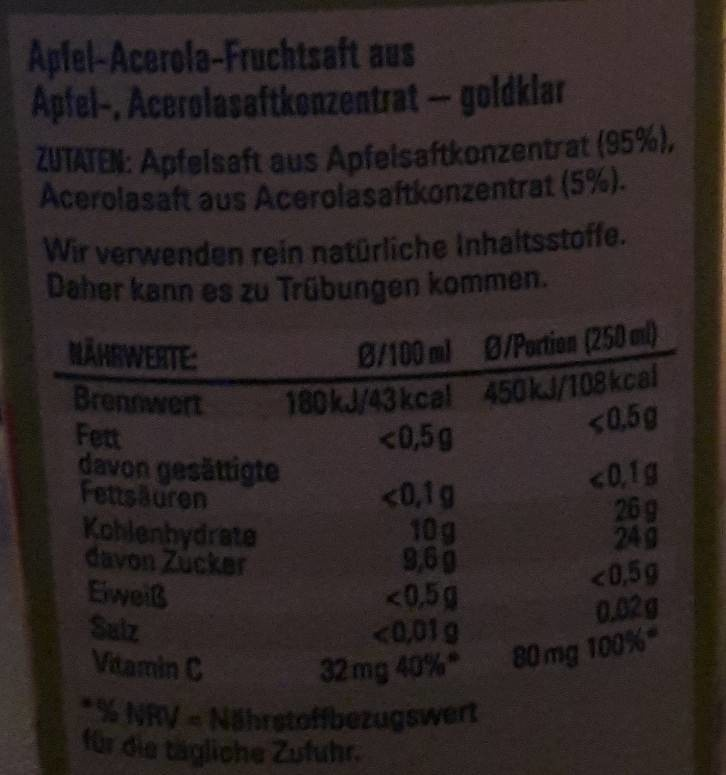

Score: 0.15
Reasons: Low resolution; Blurred image; Low contrast; Low edge density; Poor lighting variation


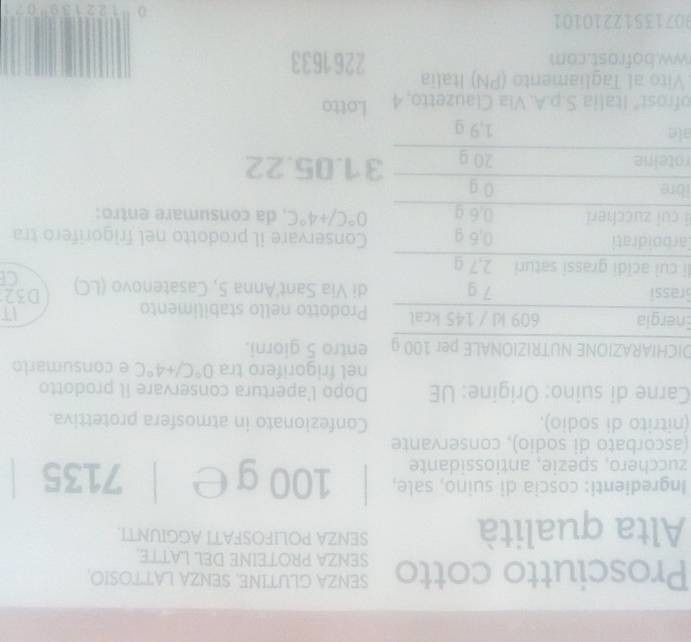

Score: 0.45
Reasons: Low resolution; Blurred image; Low contrast


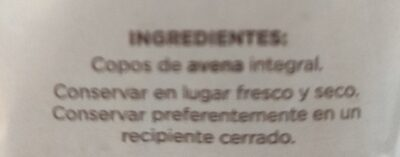

Score: 0.45
Reasons: Low resolution; Blurred image; Low edge density


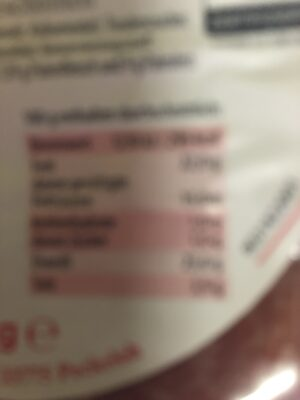

In [9]:

# ============================
# PATH (UPDATED)
# ============================
ROOT_DIR = r"D:\Y4 Research\datasets\ingredient & nutrition Images\.400 removed"
OUTPUT_CSV = r"E:\OCR\pre_ocr_suitability.csv"

results = []

# -----------------------------
# IMAGE QUALITY METRICS
# -----------------------------
def image_metrics(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    h, w = gray.shape
    resolution = h * w

    blur = cv2.Laplacian(gray, cv2.CV_64F).var()
    contrast = gray.std()
    brightness_mean = gray.mean()
    brightness_var = gray.var()

    glare_ratio = np.sum(gray > 245) / gray.size

    edges = cv2.Canny(gray, 50, 150)
    edge_density = np.sum(edges > 0) / edges.size

    return {
        "resolution": resolution,
        "blur": blur,
        "contrast": contrast,
        "brightness_mean": brightness_mean,
        "brightness_var": brightness_var,
        "glare_ratio": glare_ratio,
        "edge_density": edge_density
    }

# -----------------------------
# OCR SUITABILITY SCORING
# -----------------------------
def ocr_suitability_score(m):
    score = 1.0
    reasons = []

    if m["resolution"] < 600_000:
        score -= 0.20
        reasons.append("Low resolution")

    if m["blur"] < 80:
        score -= 0.20
        reasons.append("Blurred image")

    if m["contrast"] < 25:
        score -= 0.15
        reasons.append("Low contrast")

    if m["glare_ratio"] > 0.03:
        score -= 0.15
        reasons.append("Strong glare")

    if m["edge_density"] < 0.02:
        score -= 0.15
        reasons.append("Low edge density")

    if m["brightness_var"] < 200:
        score -= 0.15
        reasons.append("Poor lighting variation")

    return max(score, 0.0), reasons

# -----------------------------
# MAIN LOOP (UPDATED)
# -----------------------------
image_files = [
    f for f in os.listdir(ROOT_DIR)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

for img_name in tqdm(image_files, desc="Pre-OCR suitability check"):
    img_path = os.path.join(ROOT_DIR, img_name)

    img = cv2.imread(img_path)
    if img is None:
        continue

    metrics = image_metrics(img)
    suitability, reasons = ocr_suitability_score(metrics)

    results.append({
        "image_name": img_name,
        "image_path": img_path,
        **metrics,
        "ocr_suitability_score": round(suitability, 3),
        "pre_ocr_suitable": suitability >= 0.6,
        "failure_reasons": "; ".join(reasons)
    })

# -----------------------------
# DATAFRAME + SAVE
# -----------------------------
df = pd.DataFrame(results)
df.to_csv(OUTPUT_CSV, index=False)

# -----------------------------
# NUMERICAL SUMMARY
# -----------------------------
total = len(df)
suitable = df["pre_ocr_suitable"].sum()
unsuitable = total - suitable

print("\nPre-OCR Suitability Summary:")
print(f"Total images        : {total}")
print(f"Suitable for OCR    : {suitable} ({suitable/total:.2%})")
print(f"NOT suitable for OCR: {unsuitable} ({unsuitable/total:.2%})")
print(f"\nSaved → {OUTPUT_CSV}")

# -----------------------------
# BAR PLOT: SUITABLE vs UNSUITABLE
# -----------------------------
plt.figure()
plt.bar(["Suitable", "Not Suitable"], [suitable, unsuitable])
plt.ylabel("Number of Images")
plt.title("Pre-OCR Suitability Distribution")
plt.show()

# -----------------------------
# WHY NOT SUITABLE? (REASON COUNTS)
# -----------------------------
reason_counts = (
    df.loc[~df["pre_ocr_suitable"], "failure_reasons"]
      .str.split("; ")
      .explode()
      .value_counts()
)

plt.figure(figsize=(8,4))
reason_counts.plot(kind="bar")
plt.ylabel("Frequency")
plt.title("Reasons for OCR Unsuitability (Pre-OCR)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# -----------------------------
# DISPLAY SAMPLE UNSUITABLE IMAGES
# -----------------------------
print("\nExample OCR-unsuitable images:\n")

examples = df.loc[~df["pre_ocr_suitable"]].sort_values(
    "ocr_suitability_score"
).head(5)

for _, row in examples.iterrows():
    print(f"Score: {row['ocr_suitability_score']}")
    print(f"Reasons: {row['failure_reasons']}")
    display(Image.open(row["image_path"]))


Processing images (no OCR): 100%|██████████| 434/434 [00:21<00:00, 20.42it/s]


Summary Statistics (Image-only):
             width       height    resolution  mean_brightness    blur_score  \
count   434.000000   434.000000  4.340000e+02       434.000000    434.000000   
mean    985.184332   880.186636  1.516153e+06       138.386673   1700.470130   
std     931.202145   926.728588  2.923315e+06        32.614082   2697.393909   
min      91.000000    54.000000  2.160000e+04        40.089137      5.093550   
25%     400.000000   346.000000  1.136000e+05       115.364432    209.611012   
50%     448.500000   400.000000  2.156975e+05       138.793584    769.294503   
75%    1275.000000  1200.000000  1.459408e+06       160.714294   2257.900247   
max    5100.000000  4624.000000  1.603603e+07       240.464733  33451.057436   

         contrast  glare_ratio  edge_density  
count  434.000000   434.000000    434.000000  
mean    48.130795     0.012388      0.117271  
std     13.653962     0.068832      0.065575  
min     11.313402     0.000000      0.002150  
25%     38

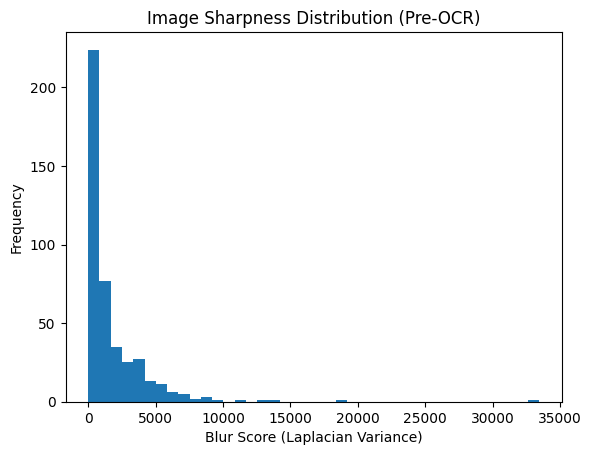

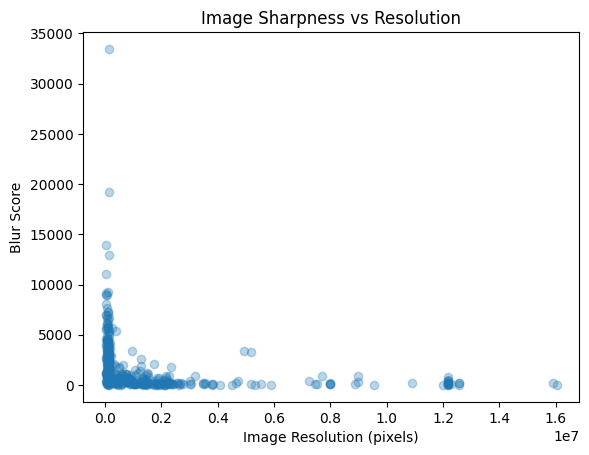

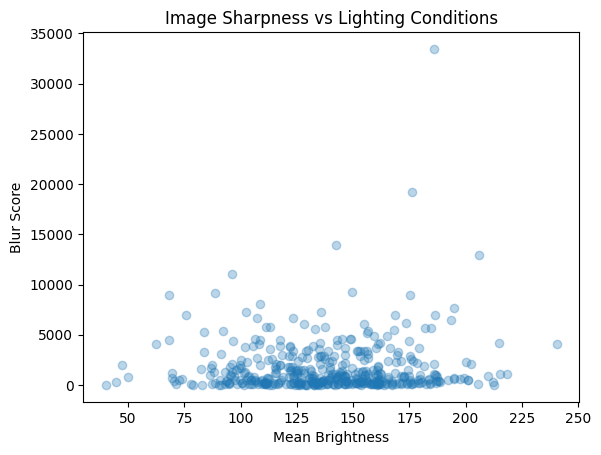

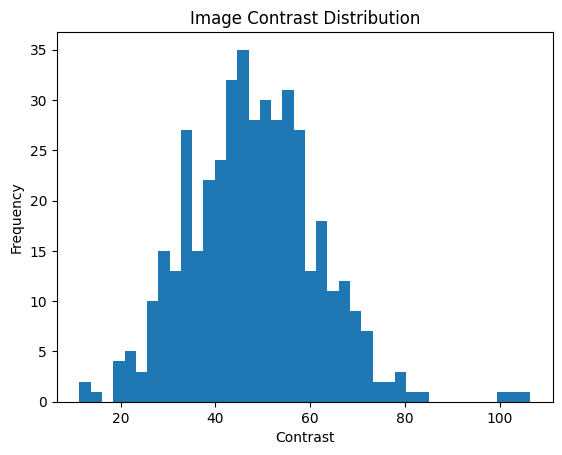

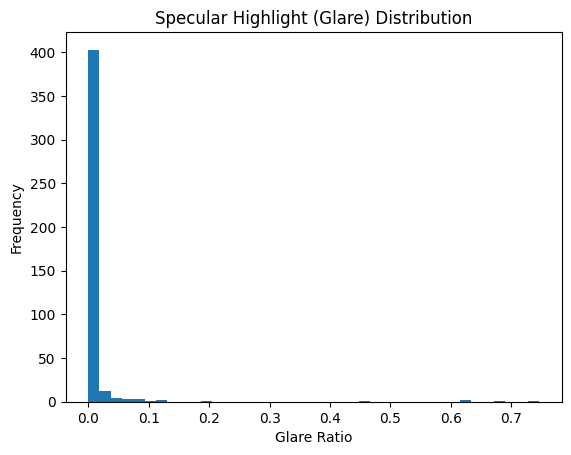


Mean Blur Score by Brightness Bin:
brightness_bin
(39.889, 80.164]      1953.800008
(80.164, 120.239]     1673.048804
(120.239, 160.314]    1494.968397
(160.314, 200.39]     2019.004424
(200.39, 240.465]     2316.985415
Name: blur_score, dtype: float64

Mean Blur Score by Resolution Bin:
resolution_bin
(21599.999, 100400.0]      3143.007864
(100400.0, 127360.0]       2391.614015
(127360.0, 632509.8]       2123.636525
(632509.8, 1850343.6]       532.171369
(1850343.6, 16036032.0]     308.148151
Name: blur_score, dtype: float64


C:\Users\rashm\AppData\Local\Temp\ipykernel_18280\1974584771.py:128: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("brightness_bin")["blur_score"].mean())
C:\Users\rashm\AppData\Local\Temp\ipykernel_18280\1974584771.py:131: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("resolution_bin")["blur_score"].mean())


In [10]:
# ============================
# PATH (UPDATED)
# ============================
ROOT_DIR = r"D:\Y4 Research\datasets\ingredient & nutrition Images\.400 removed"

# ============================
# HELPERS (IMAGE ONLY)
# ============================
def load_image(image_path):
    return cv2.imread(image_path)

def get_image_resolution(img):
    h, w = img.shape[:2]
    return w, h, w * h

def get_mean_brightness(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return gray.mean()

def get_blur_score(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

def get_contrast(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return gray.std()

def get_glare_ratio(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return np.sum(gray > 245) / gray.size

def get_edge_density(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 50, 150)
    return np.sum(edges > 0) / edges.size

# ============================
# MAIN EXTRACTION LOOP (UPDATED)
# ============================
records = []

image_files = [
    f for f in os.listdir(ROOT_DIR)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
]

for img_name in tqdm(image_files, desc="Processing images (no OCR)"):
    image_path = os.path.join(ROOT_DIR, img_name)

    img = load_image(image_path)
    if img is None:
        continue

    w, h, resolution = get_image_resolution(img)

    records.append({
        "image_name": img_name,
        "image_path": image_path,
        "width": w,
        "height": h,
        "resolution": resolution,
        "mean_brightness": get_mean_brightness(img),
        "blur_score": get_blur_score(img),
        "contrast": get_contrast(img),
        "glare_ratio": get_glare_ratio(img),
        "edge_density": get_edge_density(img)
    })

# ============================
# DATAFRAME
# ============================
df = pd.DataFrame(records)

print("\nSummary Statistics (Image-only):")
print(df.describe())

# ============================
# PLOTS
# ============================

# 1️⃣ Blur Distribution (OCR Sharpness Proxy)
plt.figure()
plt.hist(df["blur_score"], bins=40)
plt.xlabel("Blur Score (Laplacian Variance)")
plt.ylabel("Frequency")
plt.title("Image Sharpness Distribution (Pre-OCR)")
plt.show()

# 2️⃣ Blur vs Resolution
plt.figure()
plt.scatter(df["resolution"], df["blur_score"], alpha=0.3)
plt.xlabel("Image Resolution (pixels)")
plt.ylabel("Blur Score")
plt.title("Image Sharpness vs Resolution")
plt.show()

# 3️⃣ Blur vs Mean Brightness
plt.figure()
plt.scatter(df["mean_brightness"], df["blur_score"], alpha=0.3)
plt.xlabel("Mean Brightness")
plt.ylabel("Blur Score")
plt.title("Image Sharpness vs Lighting Conditions")
plt.show()

# 4️⃣ Contrast Distribution
plt.figure()
plt.hist(df["contrast"], bins=40)
plt.xlabel("Contrast")
plt.ylabel("Frequency")
plt.title("Image Contrast Distribution")
plt.show()

# 5️⃣ Glare Ratio Distribution
plt.figure()
plt.hist(df["glare_ratio"], bins=40)
plt.xlabel("Glare Ratio")
plt.ylabel("Frequency")
plt.title("Specular Highlight (Glare) Distribution")
plt.show()

# ============================
# BINNED ANALYSIS
# ============================
df["brightness_bin"] = pd.cut(df["mean_brightness"], bins=5)
df["resolution_bin"] = pd.qcut(df["resolution"], q=5, duplicates="drop")

print("\nMean Blur Score by Brightness Bin:")
print(df.groupby("brightness_bin")["blur_score"].mean())

print("\nMean Blur Score by Resolution Bin:")
print(df.groupby("resolution_bin")["blur_score"].mean())


Analyzing images (image-only): 100%|██████████| 434/434 [00:22<00:00, 19.65it/s]


--- IMAGE-ONLY AUTOMATED FINDINGS ---
Total images: 434.00
Glossy images (%): 5.53
Curved images (%): 25.12
Glossy & Curved (%): 2.30



C:\Users\rashm\AppData\Local\Temp\ipykernel_18280\2476313923.py:92: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


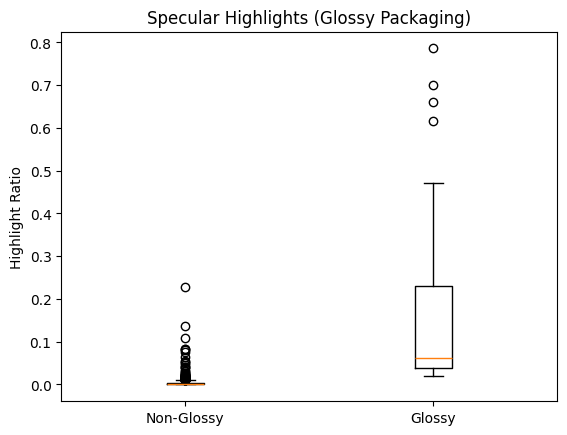

C:\Users\rashm\AppData\Local\Temp\ipykernel_18280\2476313923.py:101: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


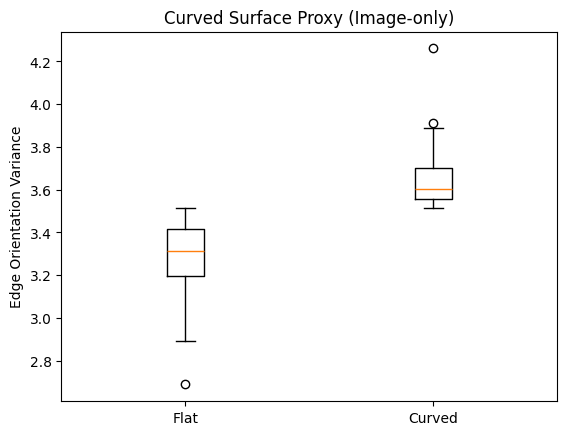

In [11]:
# ============================
# PATH (UPDATED)
# ============================
ROOT_DIR = r"D:\Y4 Research\datasets\ingredient & nutrition Images\.400 removed"

# ============================
# IMAGE METRICS (NO OCR)
# ============================
def image_metrics(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    mean_brightness = gray.mean()
    brightness_var = gray.var()

    # Specular highlight proxy (glossy packaging)
    highlight_ratio = np.sum(gray > 240) / gray.size

    return mean_brightness, brightness_var, highlight_ratio

# ============================
# CURVATURE PROXY (IMAGE-ONLY)
# ============================
def curvature_proxy_image(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 50, 150)

    ys, xs = np.where(edges > 0)
    if len(xs) < 50:
        return 0.0

    # Gradient-based orientation
    sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)

    angles = np.arctan2(sobely[ys, xs], sobelx[ys, xs])
    return np.var(angles)

# ============================
# MAIN LOOP
# ============================
rows = []

image_files = [
    f for f in os.listdir(ROOT_DIR)
    if f.lower().endswith((".jpg", ".png", ".jpeg"))
]

for img_name in tqdm(image_files, desc="Analyzing images (image-only)"):
    img_path = os.path.join(ROOT_DIR, img_name)

    img = cv2.imread(img_path)
    if img is None:
        continue

    mean_b, var_b, highlight = image_metrics(img)
    curvature = curvature_proxy_image(img)

    rows.append({
        "image_name": img_name,
        "mean_brightness": mean_b,
        "brightness_variance": var_b,
        "highlight_ratio": highlight,
        "curvature_score": curvature
    })

df = pd.DataFrame(rows)

# ============================
# THRESHOLDING (DATA-DRIVEN)
# ============================
df["glossy"] = (df["highlight_ratio"] > 0.02) & (df["mean_brightness"] > 150)
df["curved"] = df["curvature_score"] > df["curvature_score"].quantile(0.75)

# ============================
# SUMMARY STATISTICS
# ============================
summary = {
    "Total images": len(df),
    "Glossy images (%)": df["glossy"].mean() * 100,
    "Curved images (%)": df["curved"].mean() * 100,
    "Glossy & Curved (%)": (df["glossy"] & df["curved"]).mean() * 100
}

print("\n--- IMAGE-ONLY AUTOMATED FINDINGS ---")
for k, v in summary.items():
    print(f"{k}: {v:.2f}")

# ============================
# VISUAL EVIDENCE
# ============================
plt.figure()
plt.boxplot([
    df[~df["glossy"]]["highlight_ratio"],
    df[df["glossy"]]["highlight_ratio"]
], labels=["Non-Glossy", "Glossy"])
plt.ylabel("Highlight Ratio")
plt.title("Specular Highlights (Glossy Packaging)")
plt.show()

plt.figure()
plt.boxplot([
    df[~df["curved"]]["curvature_score"],
    df[df["curved"]]["curvature_score"]
], labels=["Flat", "Curved"])
plt.ylabel("Edge Orientation Variance")
plt.title("Curved Surface Proxy (Image-only)")
plt.show()
